In [6]:
import numpy as np
import matplotlib.pyplot as plt

---
## Almgren-Chriss Optimal Execution : Finance Application

This is the classical benchmark for **optimal execution**.
Given an initial inventory $q_0$, the trader liquidates over $T$ periods minimising risk-adjusted cost.

The optimal inventory trajectory under linear price impact is:

$$q_j = \frac{\sinh\bigl(\kappa(T-t_j)\bigr)}{\sinh(\kappa T)} \, q_0, \qquad \kappa = \cosh^{-1}\!\left(\frac{\tilde\kappa^2}{2}+1\right), \quad \tilde\kappa^2 = \frac{\lambda\sigma^2}{\eta\!\left(1-\frac{\gamma}{2\eta}\right)}$$

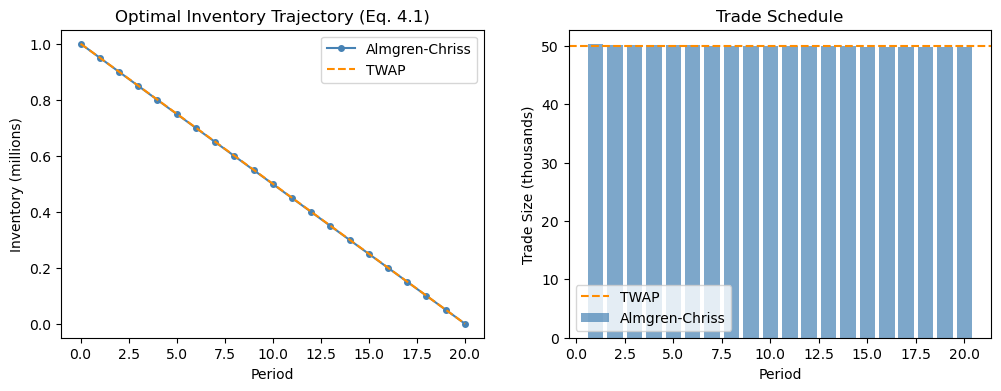

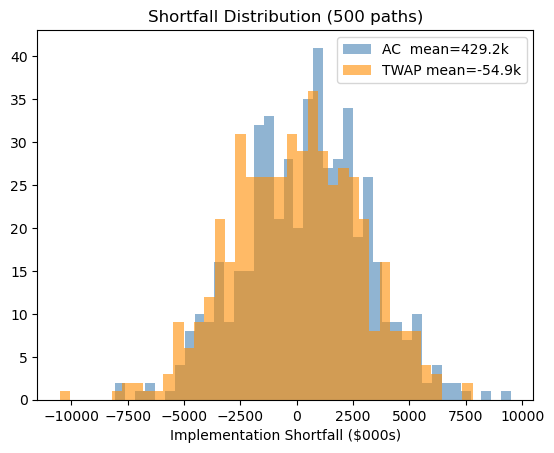

κ = 0.0065
Mean shortfall — AC: $429,195 | TWAP: $-54,913


In [7]:
class AlmgrenChrissModel:
    """
    Almgren-Chriss optimal execution model.
    Provides the analytical closed-form solution and simulation.
    
    Parameters
    q0 : initial inventory to liquidate
    T : number of trading periods
    sigma : stock price volatility (per period)
    gamma : permanent price impact coefficient
    eta : temporary price impact coefficient
    lam : risk aversion parameter
    """
    def __init__(self, q0=1e6, T=20, sigma=0.01, gamma=2.5e-7, eta=2.5e-6, lam=1e-6):
        self.q0, self.T, self.sigma = q0, T, sigma
        self.gamma, self.eta, self.lam = gamma, eta, lam

    def solve(self):
        """Compute the optimal trading trajectory."""
        gamma, eta, lam, sigma, T = self.gamma, self.eta, self.lam, self.sigma, self.T

        # kappa tilde squared
        kappa_tilde_sq = (lam * sigma**2) / (eta * (1 - gamma / (2 * eta)))
        kappa = np.arccosh(kappa_tilde_sq / 2 + 1)

        # Optimal inventory at each time point
        t = np.arange(0, T + 1)
        q = (np.sinh(kappa * (T - t)) / np.sinh(kappa * T)) * self.q0

        # Optimal trades (sell amounts)
        u = np.diff(q)  # negative = selling
        return q, -u, kappa

    def simulate(self, strategy='optimal', n_paths=500, S0=100.0):
        """
        Simulate PnL for a given execution strategy.
        strategy: 'optimal' (Almgren-Chriss) or 'twap' (Time-Weighted Average Price)
        Returns: array of implementation shortfalls
        """
        q, u_opt, _ = self.solve()
        T, q0 = self.T, self.q0

        if strategy == 'twap':
            trades = np.full(T, q0 / T)
        else:
            trades = u_opt

        shortfalls = []
        for _ in range(n_paths):
            S = S0
            proceeds = 0
            inventory = q0
            for j in range(T):
                dS = self.sigma * S * np.random.randn()
                S += dS - self.gamma * trades[j]   # permanent impact
                exec_price = S - self.eta * trades[j]  # temporary impact
                proceeds += trades[j] * exec_price
                inventory -= trades[j]

            # Implementation shortfall = cost of immediate execution - actual proceeds
            shortfalls.append(q0*S0 - proceeds)

        return np.array(shortfalls)


# Solve and plot
ac = AlmgrenChrissModel()
q_opt, u_opt, kappa = ac.solve()
q_twap = np.linspace(ac.q0, 0, ac.T + 1)

# Simulate shortfalls
sf_opt = ac.simulate('optimal')
sf_twap = ac.simulate('twap')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Inventory trajectory
axes[0].plot(q_opt / 1e6, '-o', color='steelblue', markersize=4, label='Almgren-Chriss')
axes[0].plot(q_twap / 1e6, '--', color='darkorange', label='TWAP')
axes[0].set_xlabel('Period'); axes[0].set_ylabel('Inventory (millions)')
axes[0].set_title('Optimal Inventory Trajectory (Eq. 4.1)')
axes[0].legend()

# Trade sizes
axes[1].bar(range(1, ac.T+1), u_opt/1e3, color='steelblue', alpha=0.7, label='Almgren-Chriss')
axes[1].axhline(ac.q0/ac.T/1e3, color='darkorange', linestyle='--', label='TWAP')
axes[1].set_xlabel('Period'); axes[1].set_ylabel('Trade Size (thousands)')
axes[1].set_title('Trade Schedule')
axes[1].legend()
plt.show()

# Shortfall distribution
plt.plot(figsize =(10,8))
plt.hist(sf_opt/1e3, bins=40, alpha=0.6, color='steelblue', label=f'AC  mean={sf_opt.mean()/1e3:.1f}k')
plt.hist(sf_twap/1e3, bins=40, alpha=0.6, color='darkorange', label=f'TWAP mean={sf_twap.mean()/1e3:.1f}k')
plt.xlabel('Implementation Shortfall ($000s)')
plt.title('Shortfall Distribution (500 paths)')
plt.legend()

plt.show()
print(f"κ = {kappa:.4f}")
print(f"Mean shortfall — AC: ${sf_opt.mean():,.0f} | TWAP: ${sf_twap.mean():,.0f}")